In [2]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Warnings
import warnings
warnings.filterwarnings('ignore')

## Loading Data

In [6]:
# Load datasets
train_df = pd.read_csv('/home/grow-lt-357/Documents/codex - 2/data/train.csv')
test_df = pd.read_csv('/home/grow-lt-357/Documents/codex - 2/data/test.csv')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

# Preview
display(train_df.head())
display(test_df.head())

Train Shape: (3800, 18)
Test Shape: (950, 17)


,patient_id,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d
0,PID10000,2020-01-01,24.0,M,1,1,Tue,1.8,7.0,6.0,2,Private,100.4,112.30,132.5,0.82,10.3,0
1,PID10001,01/01/2020,73.0,F,1,1,Thu,14.7,2.0,2.0,14,Medicaid,114.3,166.10,154.3,1.32,10.6,0
2,PID10002,01/01/2020,65.0,F,1,3,Wed,10.6,0.0,0.0,3,Private,106.4,17.69,133.8,1.08,13.6,0
3,PID10003,2020-01-01,49.0,M,2,1,Fri,9.1,0.0,0.0,9,Medicaid,97.4,131.90,149.8,0.64,13.5,0
4,PID10004,2020-01-02,49.0,F,1,1,Thu,7.5,0.0,0.0,7,Medicare,NaN,137.30,142.4,2.26,11.9,0


,patient_id,admission_date,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl
0,PID10000,2020-01-01,89.0,F,2,1,Sun,12.2,1.0,1.0,15,Medicare,64.1,120.3,138.3,1.57,10.5
1,PID10001,2020-01-01,85.0,M,2,2,Thu,8.1,0.0,1.0,5,Uninsured,142.4,130.4,138.5,1.03,11.1
2,PID10002,01/01/2020,55.0,F,1,3,Wed,1.7,2.0,1.0,12,Medicaid,109.9,130.8,142.8,1.30,11.1
3,PID10003,2020-01-01,66.0,F,1,1,Sun,20.5,2.0,2.0,7,Medicare,136.5,102.4,138.8,1.21,13.7
4,PID10004,02/01/2020,70.0,M,1,3,Wed,4.4,1.0,0.0,17,Medicare,60.0,140.8,130.6,0.71,14.1


In [5]:
# Info
print("Train Info:")
train_df.info()

print("\nTest Info:")
test_df.info()

# Describe numerical features
display(train_df.describe())

# Describe categorical features
display(train_df.describe(include='object'))

Train Info:
<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   admission_date              3800 non-null   str    
 1   age                         3800 non-null   float64
 2   gender                      3800 non-null   str    
 3   admission_type              3800 non-null   int64  
 4   discharge_destination       3800 non-null   int64  
 5   discharge_day_of_week       3800 non-null   str    
 6   length_of_stay_days         3800 non-null   float64
 7   charlson_comorbidity_index  3800 non-null   float64
 8   prior_admissions_1yr        3800 non-null   float64
 9   n_medications_discharge     3800 non-null   int64  
 10  insurance_type              3800 non-null   str    
 11  glucose_level_mgdl          3127 non-null   float64
 12  blood_pressure_systolic     3800 non-null   float64
 13  sodium_meql                 3800

,age,admission_type,discharge_destination,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3127.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,56.566842,1.542105,1.656579,7.247921,2.268421,2.152105,9.699737,104.443780,114.079995,137.855211,1.199868,12.471132,0.090000
std,56.968099,0.658486,0.923051,4.816102,2.271643,2.133976,5.768190,26.450105,40.952359,3.992365,0.500145,1.975551,0.286219
min,18.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,60.000000,10.670000,125.000000,0.400000,6.000000,0.000000
25%,35.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,85.100000,106.300000,135.100000,0.860000,11.100000,0.000000
50%,53.000000,1.000000,1.000000,6.000000,2.000000,2.000000,10.000000,103.600000,124.200000,137.700000,1.110000,12.500000,0.000000
75%,72.000000,2.000000,2.000000,9.100000,3.000000,3.000000,15.000000,122.400000,138.800000,140.500000,1.430000,13.800000,0.000000
max,999.000000,3.000000,4.000000,45.100000,10.000000,11.000000,19.000000,188.000000,209.800000,154.300000,4.910000,18.000000,1.000000


,admission_date,gender,discharge_day_of_week,insurance_type
count,3800,3800,3800,3800
unique,1755,2,7,4
top,2020-01-08,M,Fri,Medicare
freq,4,1935,571,1435


## Removing unncessary cols

In [7]:
train_df.drop(columns=['patient_id'], inplace=True)
test_df.drop(columns=['patient_id'], inplace=True)

In [8]:
train_df.shape

(3800, 17)

## outliers

In [9]:
train_df['age'] = train_df['age'].replace(999, np.nan)

## Converting Date

In [10]:
train_df['admission_date'] = pd.to_datetime(
    train_df['admission_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

train_df['admission_month'] = train_df['admission_date'].dt.month
train_df['admission_day'] = train_df['admission_date'].dt.day
train_df['admission_weekday'] = train_df['admission_date'].dt.weekday

train_df.drop(columns=['admission_date'], inplace=True)

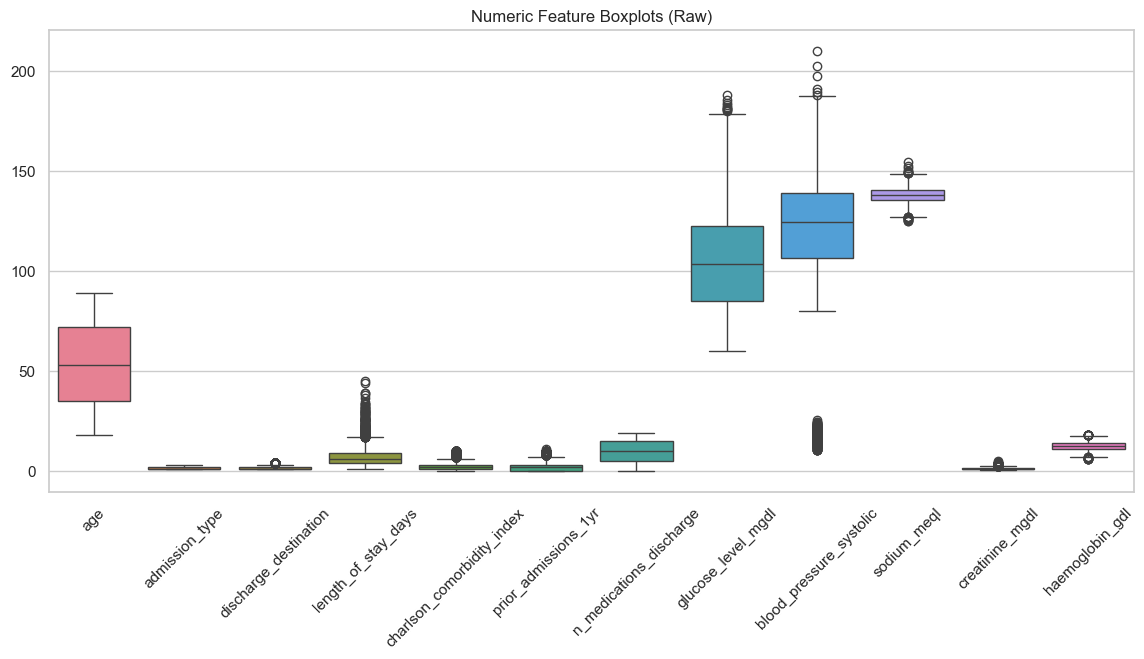

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Optional: remove target if present
target_col = 'readmitted_30d'
if target_col in num_cols:
    num_cols.remove(target_col)

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(data=train_df[num_cols])

plt.title("Numeric Feature Boxplots (Raw)")
plt.xticks(rotation=45)
plt.show()

## Missing value mitigation 

In [12]:
cat_like_cols = ['admission_type', 'discharge_destination']

for col in cat_like_cols:
    train_df[col] = train_df[col].astype('category')

Missing Values:
 glucose_level_mgdl    673
age                    12
dtype: int64


,count,percent
glucose_level_mgdl,673,17.710526
age,12,0.315789


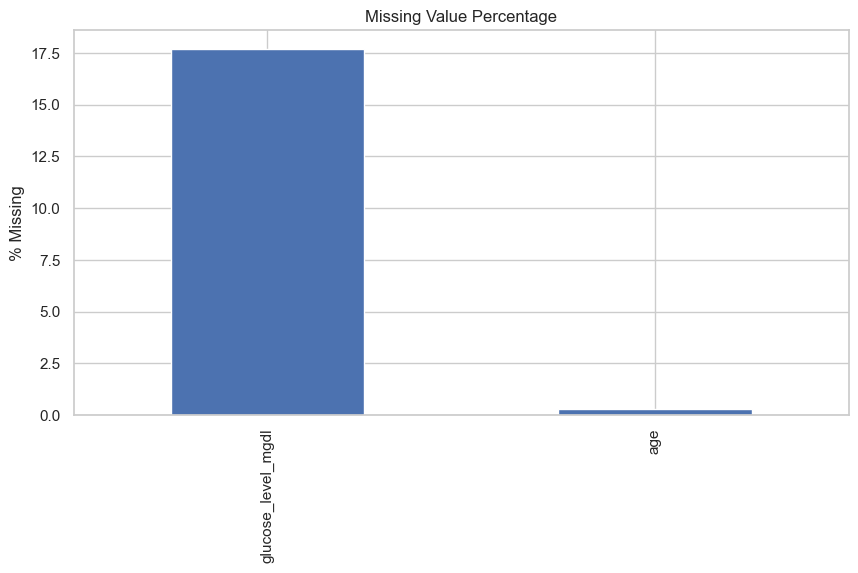

In [13]:
# Missing values count
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing Values:\n", missing)

# Percentage
missing_percent = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({
    'count': missing,
    'percent': missing_percent
})

display(missing_df)

# Visualization
plt.figure(figsize=(10,5))
missing_percent.plot(kind='bar')
plt.title("Missing Value Percentage")
plt.ylabel("% Missing")
plt.show()

In [14]:
train_df['glucose_missing'] = train_df['glucose_level_mgdl'].isnull().astype(int)

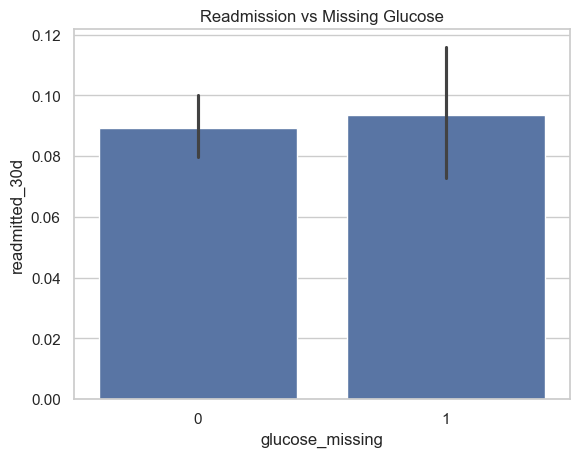

In [15]:
sns.barplot(x='glucose_missing', y='readmitted_30d', data=train_df)
plt.title("Readmission vs Missing Glucose")
plt.show()

## Median Imputation 

In [16]:
median_val = train_df['glucose_level_mgdl'].median()

train_df['glucose_level_mgdl'].fillna(median_val, inplace=True)
test_df['glucose_level_mgdl'].fillna(median_val, inplace=True)

0       64.1
1      142.4
2      109.9
3      136.5
4       60.0
       ...  
945    108.9
946     86.4
947     97.5
948     61.4
949     63.0
Name: glucose_level_mgdl, Length: 950, dtype: float64

## Target Value Analysis - CLass IMbalance

readmitted_30d
0    3458
1     342
Name: count, dtype: int64
readmitted_30d
0    0.91
1    0.09
Name: proportion, dtype: float64


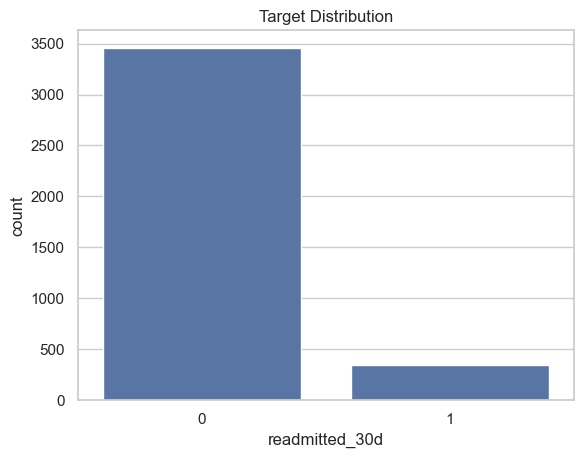

In [17]:


# Assuming target column name (change if different)
target_col = 'readmitted_30d'

# Value counts
print(train_df[target_col].value_counts())

# Percentage
print(train_df[target_col].value_counts(normalize=True))

# Plot
sns.countplot(x=train_df[target_col])
plt.title("Target Distribution")
plt.show()

## Identify Feature types

In [18]:
# Separate column types
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove target from num_cols if present
if target_col in num_cols:
    num_cols.remove(target_col)

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['age', 'length_of_stay_days', 'charlson_comorbidity_index', 'prior_admissions_1yr', 'n_medications_discharge', 'glucose_level_mgdl', 'blood_pressure_systolic', 'sodium_meql', 'creatinine_mgdl', 'haemoglobin_gdl', 'glucose_missing']
Categorical Columns: ['gender', 'discharge_day_of_week', 'insurance_type']


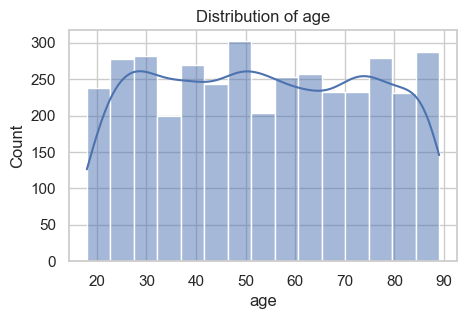

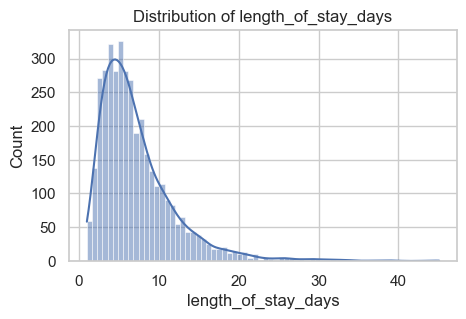

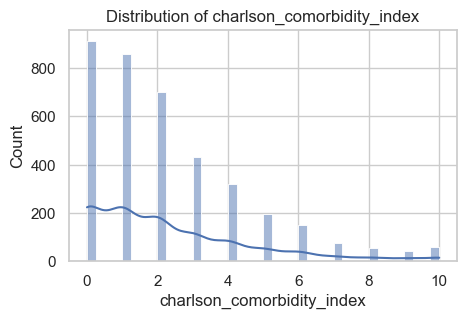

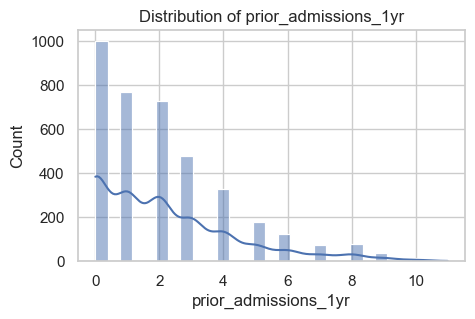

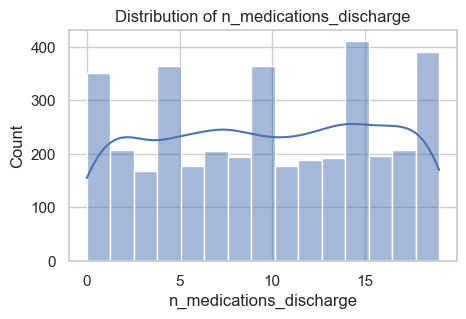

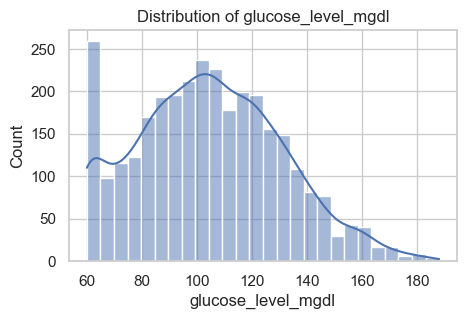

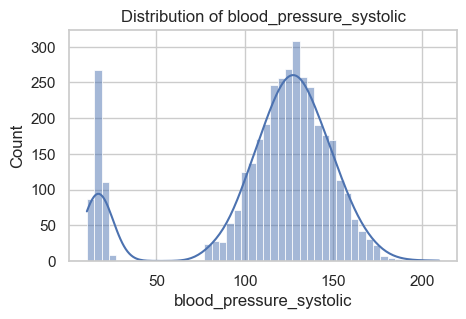

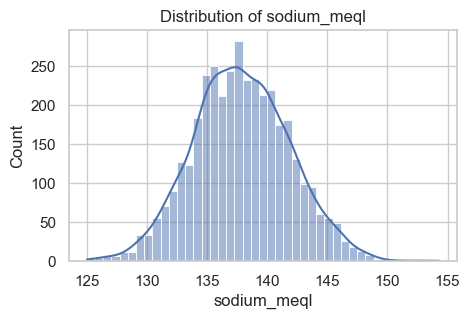

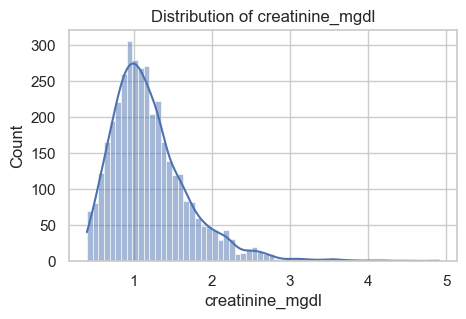

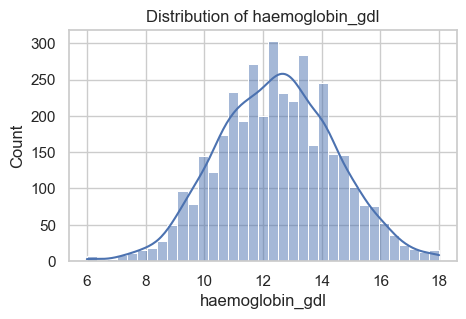

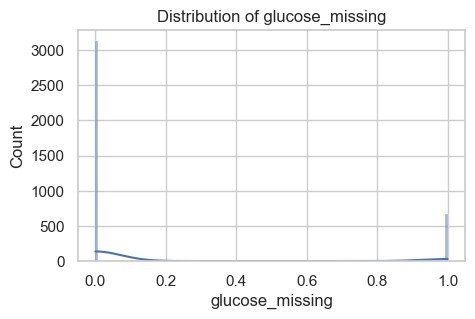

In [19]:
# Distribution plots
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Blood_pressure problem

In [20]:
low_bp_count = (train_df['blood_pressure_systolic'] < 50).sum()
print(f"Values < 50: {low_bp_count}")

Values < 50: 473


In [21]:
# Convert suspected kPa → mmHg
mask = train_df['blood_pressure_systolic'] < 50

train_df.loc[mask, 'blood_pressure_systolic'] = (
    train_df.loc[mask, 'blood_pressure_systolic'] * 7.50062
)


mask_test = test_df['blood_pressure_systolic'] < 50

test_df.loc[mask_test, 'blood_pressure_systolic'] = (
    test_df.loc[mask_test, 'blood_pressure_systolic'] * 7.50062
)

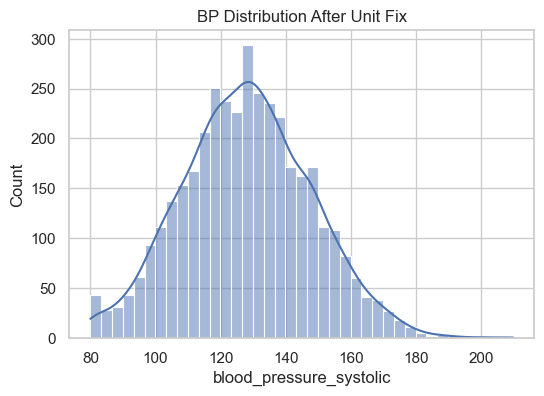

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(train_df['blood_pressure_systolic'], kde=True)
plt.title("BP Distribution After Unit Fix")
plt.show()

In [23]:
train_df.to_csv("train_df.csv")
test_df.to_csv("test_df.csv")

In [26]:
train_df

,age,gender,admission_type,discharge_destination,discharge_day_of_week,length_of_stay_days,charlson_comorbidity_index,prior_admissions_1yr,n_medications_discharge,insurance_type,glucose_level_mgdl,blood_pressure_systolic,sodium_meql,creatinine_mgdl,haemoglobin_gdl,readmitted_30d,admission_month,admission_day,admission_weekday,glucose_missing
0,24.0,M,1,1,Tue,1.8,7.0,6.0,2,Private,100.4,112.300000,132.5,0.82,10.3,0,1,1,2,0
1,73.0,F,1,1,Thu,14.7,2.0,2.0,14,Medicaid,114.3,166.100000,154.3,1.32,10.6,0,1,1,2,0
2,65.0,F,1,3,Wed,10.6,0.0,0.0,3,Private,106.4,132.685968,133.8,1.08,13.6,0,1,1,2,0
3,49.0,M,2,1,Fri,9.1,0.0,0.0,9,Medicaid,97.4,131.900000,149.8,0.64,13.5,0,1,1,2,0
4,49.0,F,1,1,Thu,7.5,0.0,0.0,7,Medicare,NaN,137.300000,142.4,2.26,11.9,0,2,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,37.0,M,1,4,Sat,6.6,7.0,7.0,4,Private,114.6,132.800000,139.3,1.85,11.2,1,8,6,5,0
3796,67.0,F,2,1,Sat,3.9,4.0,4.0,13,Private,NaN,116.700000,135.2,0.81,13.5,0,7,8,4,1
3797,22.0,F,2,1,Sun,10.9,3.0,3.0,12,Private,NaN,165.500000,135.1,1.42,11.8,0,8,7,6,1
3798,18.0,F,1,1,Thu,4.1,6.0,5.0,16,Uninsured,70.9,115.300000,144.2,1.49,9.0,1,7,8,4,0


In [27]:
train_df['glucose_level_mgdl'].isnull().sum()

np.int64(673)